# Vibe-Aware Vocabulary Pruning: Benchmarking a Dual-Encoder Router for LLM Inference

This notebook implements and benchmarks four vocabulary routing strategies against a full-vocabulary baseline:

| Section | Method |
|---------|--------|
| 1 | Baseline profiling (full vocab) |
| 2 | Vocab space exploration (PCA/UMAP) |
| 3 | Static Top-K + Cosine router |
| 4 | Cluster-based router (k-means) |
| 5 | **Dual-Encoder router (MNRL)** — main contribution |
| 6 | Pareto charts: accuracy vs. speed |
| 7 | Discussion |

All pruned-vocabulary metrics are reported **relative to the full-vocabulary baseline**.

## 0. Setup, Imports, Hardware Info

In [8]:
import time
import math
import random
import warnings
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device selection: MPS > CUDA > CPU
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
if DEVICE.type == 'mps':
    print('Backend: Apple MPS')
elif DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: mps
PyTorch: 2.11.0
Backend: Apple MPS


In [9]:
# ── Configuration ────────────────────────────────────────────────────────────
MODEL_NAME = 'meta-llama/Llama-3.2-1B-Instruct'
# Fallback if Llama requires gating:
# MODEL_NAME = 'microsoft/Phi-3-mini-4k-instruct'

DATASET_NAME = 'wikitext'
DATASET_CONFIG = 'wikitext-2-raw-v1'

K_VALUES = [512, 1_000, 2_000, 5_000, 10_000]  # shortlist sizes to sweep
N_BENCH_PROMPTS = 50          # prompts for latency benchmarks
BENCH_MAX_NEW_TOKENS = 64     # tokens generated per prompt in latency runs
PPL_MAX_TOKENS = 4096         # tokens used for perplexity evaluation
ROUTER_TRAIN_EPOCHS = 3
ROUTER_BATCH_SIZE = 256
ROUTER_LR = 3e-4
ROUTER_HIDDEN_DIM = 512       # MLP hidden dim
ROUTER_OUT_DIM = 256          # projected query dim
TEMPERATURE = 0.05            # InfoNCE temperature
PREFIX_FRAC_LOW = 0.4
PREFIX_FRAC_HIGH = 0.7
N_KMEANS_CLUSTERS = 256       # for cluster router

# ── Dual-Encoder (completion-based) config ───────────────────────────────────
COMPLETION_LEN = 16           # tokens per completion in the corpus
N_INDEX_COMPLETIONS = 8000    # number of completions in the retrieval index
N_TRAIN_PAIRS = 5000          # (prefix, completion) pairs for router training
N_RETRIEVE = 32               # K completions to retrieve at inference
REFRESH_EVERY = 16            # re-query index every N generated tokens and union-expand shortlist

# ── Method 6: Attention Graph config ─────────────────────────────────────────
ATTN_TOP_POSITIONS = 16       # top attended positions to collect per step
ATTN_NEIGHBOUR_K = 64         # lm_head nearest neighbours per attended token
ATTN_AGG = 'last_layer_mean'  # aggregation: last layer, mean over heads

# ── Method 7: MLP Transition Graph config ────────────────────────────────────
GRAPH_EDGES_PER_NODE = 32     # outgoing edges per token node (top-M by logit)
GRAPH_PROBE_LAYERS = 'all'    # 'all' = pass through all MLP layers sequentially
GRAPH_ANCHOR_K = 16           # top-K anchor nodes from cosine(h_T, lm_head)

# ── Method 8: Vibe-aware Speculative Decoding config ─────────────────────────
SPEC_DRAFT_LEN = 4            # number of draft tokens per speculative step
SPEC_N_PROMPTS = 50           # prompts for spec decoding benchmark
SPEC_MAX_NEW_TOKENS = 64      # tokens to generate per prompt

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

## 0.1 Load Model and Tokenizer

In [10]:
print(f'Loading tokenizer and model: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map='auto' if DEVICE.type != 'mps' else None,
)
if DEVICE.type == 'mps':
    model = model.to(DEVICE)
model.eval()

VOCAB_SIZE = model.config.vocab_size
HIDDEN_DIM = model.config.hidden_size
print(f'Vocab size: {VOCAB_SIZE:,}')
print(f'Hidden dim: {HIDDEN_DIM}')
print(f'Model dtype: {next(model.parameters()).dtype}')

# Extract the vocabulary embedding matrix (lm_head weights) as float32 on CPU
# Shape: [vocab_size, hidden_dim]
with torch.no_grad():
    lm_head_weight = model.lm_head.weight.detach().float().cpu()
print(f'lm_head weight shape: {lm_head_weight.shape}')

# Pre-normalised vocabulary embeddings for cosine lookups
lm_head_norm = F.normalize(lm_head_weight, dim=-1)  # [V, d]

Loading tokenizer and model: meta-llama/Llama-3.2-1B-Instruct


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Vocab size: 128,256
Hidden dim: 2048
Model dtype: torch.bfloat16
lm_head weight shape: torch.Size([128256, 2048])


## 0.2 Load Dataset

In [11]:
raw_dataset = load_dataset(DATASET_NAME, DATASET_CONFIG)
print(raw_dataset)

def get_text_chunks(split: str, chunk_tokens: int = 128, n_chunks: int = None) -> List[torch.Tensor]:
    """Tokenise the split and return a list of fixed-length token tensors.
    Lines are encoded individually and concatenated to avoid passing a
    super-long string that exceeds the model's maximum sequence length.
    """
    lines = [line for line in raw_dataset[split]['text'] if len(line.strip()) > 20]
    parts = [
        tokenizer.encode(line, return_tensors='pt')[0]
        for line in lines
    ]
    tokens = torch.cat(parts)
    chunks = [tokens[i:i+chunk_tokens] for i in range(0, len(tokens) - chunk_tokens, chunk_tokens)]
    if n_chunks is not None:
        chunks = chunks[:n_chunks]
    return chunks

bench_prompts = get_text_chunks('validation', chunk_tokens=128, n_chunks=N_BENCH_PROMPTS)
print(f'Benchmark prompts: {len(bench_prompts)} x 128 tokens')

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})
Benchmark prompts: 50 x 128 tokens


---
## 1. Baseline Profiling

Measure:
- Overall tokens/sec with full-vocabulary decoding
- Fraction of per-token time consumed by the `lm_head` projection

In [14]:
def timed_lm_head(hidden: torch.Tensor, weight: torch.Tensor) -> Tuple[torch.Tensor, float]:
    """Run lm_head projection and return (logits, elapsed_seconds)."""
    if DEVICE.type == 'mps':
        torch.mps.synchronize()
    elif DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    logits = hidden @ weight.T
    if DEVICE.type == 'mps':
        torch.mps.synchronize()
    elif DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    return logits, time.perf_counter() - t0


def baseline_decode_with_profile(
    input_ids: torch.Tensor,
    max_new_tokens: int = BENCH_MAX_NEW_TOKENS,
) -> Dict:
    """Greedy decode with full vocab; track per-step timings."""
    input_ids = input_ids.unsqueeze(0).to(DEVICE)
    past_key_values = None
    total_times, lmhead_times = [], []

    with torch.no_grad():
        for _ in range(max_new_tokens):
            t_start = time.perf_counter()

            out = model(
                input_ids=input_ids if past_key_values is None else input_ids[:, -1:],
                past_key_values=past_key_values,
                use_cache=True,
                output_hidden_states=True,
            )
            hidden = out.hidden_states[-1][:, -1, :]  # [1, d]
            past_key_values = out.past_key_values

            lm_w = model.lm_head.weight  # on device
            logits, lmhead_t = timed_lm_head(hidden, lm_w)

            next_token = logits[0].argmax(dim=-1, keepdim=True).unsqueeze(0)
            input_ids = next_token

            if DEVICE.type == 'mps':
                torch.mps.synchronize()
            t_end = time.perf_counter()

            total_times.append(t_end - t_start)
            lmhead_times.append(lmhead_t)

    return {
        'total_times': total_times,
        'lmhead_times': lmhead_times,
    }


print('Running baseline profiling (this may take a few minutes)...')
# Warm-up
_ = baseline_decode_with_profile(bench_prompts[0], max_new_tokens=5)

baseline_results = []
for prompt in tqdm(bench_prompts, desc='Baseline profiling'):
    r = baseline_decode_with_profile(prompt)
    baseline_results.append(r)

all_total = np.array([t for r in baseline_results for t in r['total_times']])
all_lmhead = np.array([t for r in baseline_results for t in r['lmhead_times']])

baseline_tps = 1.0 / all_total.mean()
lmhead_frac = all_lmhead.mean() / all_total.mean()

print(f'\n=== Baseline Results ===')
print(f'Tokens/sec:            {baseline_tps:.2f}')
print(f'Mean total time/token: {all_total.mean()*1000:.2f} ms')
print(f'Mean lm_head time:     {all_lmhead.mean()*1000:.2f} ms')
print(f'lm_head fraction:      {lmhead_frac*100:.1f}%')

# Save
baseline_summary = {
    'tokens_per_sec': baseline_tps,
    'mean_total_ms': all_total.mean() * 1000,
    'mean_lmhead_ms': all_lmhead.mean() * 1000,
    'lmhead_frac': lmhead_frac,
}
pd.DataFrame([baseline_summary]).to_csv(RESULTS_DIR / 'baseline_summary.csv', index=False)

Running baseline profiling (this may take a few minutes)...


Baseline profiling:   0%|          | 0/50 [00:00<?, ?it/s]


=== Baseline Results ===
Tokens/sec:            22.33
Mean total time/token: 44.79 ms
Mean lm_head time:     6.21 ms
lm_head fraction:      13.9%


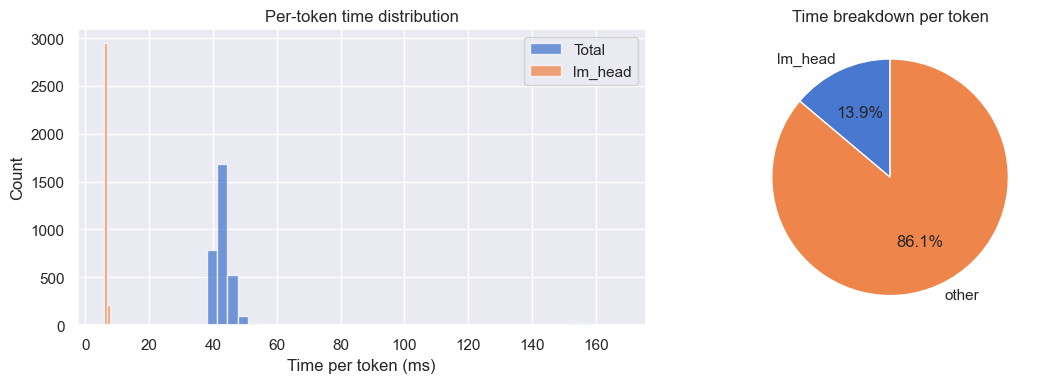

In [15]:
# Visualise baseline timing breakdown
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(all_total * 1000, bins=40, alpha=0.75, label='Total')
axes[0].hist(all_lmhead * 1000, bins=40, alpha=0.75, label='lm_head')
axes[0].set_xlabel('Time per token (ms)')
axes[0].set_ylabel('Count')
axes[0].set_title('Per-token time distribution')
axes[0].legend()

labels = ['lm_head', 'other']
sizes = [lmhead_frac, 1 - lmhead_frac]
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Time breakdown per token')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'baseline_profile.png', dpi=150)
plt.show()

---
## 2. Vocabulary Space Exploration

Visualise the token embedding space to understand cluster structure before designing routers.

In [ ]:
print('Reducing vocabulary embeddings with PCA...')
# Sample 8k tokens for visualisation speed
vis_idx = np.random.choice(VOCAB_SIZE, size=min(8000, VOCAB_SIZE), replace=False)
vis_emb = lm_head_weight[vis_idx].numpy()  # [8000, d]

pca = PCA(n_components=2, random_state=SEED)
vis_2d = pca.fit_transform(vis_emb)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(vis_2d[:, 0], vis_2d[:, 1], s=1, alpha=0.3)
ax.set_title(f'Token embedding PCA (n={len(vis_idx):,} sampled tokens)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
explained = pca.explained_variance_ratio_.sum() * 100
ax.text(0.02, 0.98, f'Explained variance: {explained:.1f}%',
        transform=ax.transAxes, va='top')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'vocab_pca.png', dpi=150)
plt.show()

In [ ]:
# Optional UMAP (skip if umap-learn not installed)
try:
    import umap
    print('Reducing with UMAP (this takes ~1-2 min)...')
    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                        random_state=SEED, verbose=False)
    vis_umap = reducer.fit_transform(vis_emb)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(vis_umap[:, 0], vis_umap[:, 1], s=1, alpha=0.3)
    ax.set_title(f'Token embedding UMAP (n={len(vis_idx):,})')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'vocab_umap.png', dpi=150)
    plt.show()
except ImportError:
    print('umap-learn not installed, skipping UMAP visualisation.')

---
## 3. Static and Cosine Router Baselines

- **Static Top-K:** always keep the K tokens with the highest `lm_head` weight L2-norm (context-free).
- **Cosine router:** at each step, keep the K tokens with highest cosine similarity to the current hidden state.

In [ ]:
# Pre-compute static top-K indices (sorted by weight norm, descending)
token_norms = lm_head_weight.norm(dim=-1)  # [V]
static_sorted_idx = token_norms.argsort(descending=True)  # [V]

def get_static_shortlist(k: int) -> torch.Tensor:
    return static_sorted_idx[:k]

def get_cosine_shortlist(hidden: torch.Tensor, k: int) -> torch.Tensor:
    """hidden: [d] float32 on CPU."""
    h_norm = F.normalize(hidden.unsqueeze(0), dim=-1)  # [1, d]
    sims = (h_norm @ lm_head_norm.T).squeeze(0)        # [V]
    return sims.topk(k).indices                         # [k]

In [ ]:
def evaluate_router(
    router_fn,           # callable(hidden_cpu, k) -> LongTensor of k indices
    k: int,
    n_prompts: int = N_BENCH_PROMPTS,
    max_new_tokens: int = BENCH_MAX_NEW_TOKENS,
) -> Dict:
    """
    Run greedy decode with a pruned vocabulary.
    Returns tokens/sec, acceptance rate (vs full-vocab greedy), lmhead_frac.
    """
    accepted, total_steps = 0, 0
    total_times, lmhead_times = [], []

    for prompt in tqdm(bench_prompts[:n_prompts], desc=f'K={k}', leave=False):
        input_ids = prompt.unsqueeze(0).to(DEVICE)
        past_key_values = None

        with torch.no_grad():
            for _ in range(max_new_tokens):
                t_start = time.perf_counter()

                out = model(
                    input_ids=input_ids if past_key_values is None else input_ids[:, -1:],
                    past_key_values=past_key_values,
                    use_cache=True,
                    output_hidden_states=True,
                )
                hidden = out.hidden_states[-1][:, -1, :]  # [1, d] on device
                past_key_values = out.past_key_values

                # Full-vocab greedy token (reference)
                full_logits = hidden @ model.lm_head.weight.T  # [1, V]
                gold_token = full_logits[0].argmax().item()

                # Router shortlist
                hidden_cpu = hidden[0].float().cpu()
                shortlist = router_fn(hidden_cpu, k)  # [k]

                # Pruned lm_head
                pruned_weight = model.lm_head.weight[shortlist]  # [k, d]
                t_lm0 = time.perf_counter()
                pruned_logits = hidden @ pruned_weight.T  # [1, k]
                if DEVICE.type == 'mps':
                    torch.mps.synchronize()
                t_lm1 = time.perf_counter()

                # Map pruned argmax back to vocab
                pruned_best_local = pruned_logits[0].argmax().item()
                pruned_best_token = shortlist[pruned_best_local].item()

                accepted += int(pruned_best_token == gold_token)
                total_steps += 1

                # Next input: use gold token to keep decode on track
                input_ids = torch.tensor([[gold_token]], device=DEVICE)

                if DEVICE.type == 'mps':
                    torch.mps.synchronize()
                t_end = time.perf_counter()

                total_times.append(t_end - t_start)
                lmhead_times.append(t_lm1 - t_lm0)

    arr_total = np.array(total_times)
    arr_lm = np.array(lmhead_times)
    return {
        'k': k,
        'acceptance_rate': accepted / total_steps,
        'tokens_per_sec': 1.0 / arr_total.mean(),
        'lmhead_frac': arr_lm.mean() / arr_total.mean(),
        'mean_total_ms': arr_total.mean() * 1000,
        'mean_lmhead_ms': arr_lm.mean() * 1000,
    }


def compute_perplexity(
    router_fn,
    k: int,
    max_tokens: int = PPL_MAX_TOKENS,
) -> float:
    """
    Compute perplexity on WikiText-2 test split using pruned logits.
    Returns perplexity value.
    """
    lines = [line for line in raw_dataset['test']['text'] if len(line.strip()) > 20]
    parts = [
        tokenizer.encode(line, return_tensors='pt')[0]
        for line in lines
    ]
    tokens = torch.cat(parts)[:max_tokens]
    input_ids = tokens.unsqueeze(0).to(DEVICE)

    stride = 512
    seq_len = input_ids.size(1)
    nlls = []

    with torch.no_grad():
        for begin in tqdm(range(0, seq_len - 1, stride), desc=f'PPL K={k}', leave=False):
            end = min(begin + stride, seq_len - 1)
            chunk = input_ids[:, begin:end + 1]
            out = model(
                input_ids=chunk,
                output_hidden_states=True,
            )
            hiddens = out.hidden_states[-1][:, :-1, :]  # [1, T-1, d]
            targets = chunk[:, 1:]                      # [1, T-1]

            for t in range(hiddens.size(1)):
                h = hiddens[0, t].float().cpu()         # [d]
                shortlist = router_fn(h, k)             # [k]
                pruned_w = model.lm_head.weight[shortlist].float().cpu()
                logits = h @ pruned_w.T                 # [k]
                target = targets[0, t].item()

                # If gold token in shortlist, compute true NLL; else assign max NLL
                if target in shortlist.tolist():
                    local_idx = (shortlist == target).nonzero(as_tuple=True)[0][0].item()
                    nll = -F.log_softmax(logits, dim=-1)[local_idx].item()
                else:
                    nll = -math.log(1e-9)  # penalise blind spots heavily
                nlls.append(nll)

    return math.exp(np.mean(nlls))

In [ ]:
# Compute full-vocab perplexity baseline
def full_vocab_ppl(max_tokens: int = PPL_MAX_TOKENS) -> float:
    lines = [line for line in raw_dataset['test']['text'] if len(line.strip()) > 20]
    parts = [
        tokenizer.encode(line, return_tensors='pt')[0]
        for line in lines
    ]
    tokens = torch.cat(parts)[:max_tokens]
    input_ids = tokens.unsqueeze(0).to(DEVICE)
    stride = 512
    seq_len = input_ids.size(1)
    nlls = []
    with torch.no_grad():
        for begin in tqdm(range(0, seq_len - 1, stride), desc='PPL baseline', leave=False):
            end = min(begin + stride, seq_len - 1)
            chunk = input_ids[:, begin:end + 1]
            out = model(input_ids=chunk)
            logits = out.logits[0, :-1, :]   # [T-1, V]
            targets = chunk[0, 1:]            # [T-1]
            nll = F.cross_entropy(logits, targets, reduction='none')
            nlls.extend(nll.float().cpu().tolist())
    return math.exp(np.mean(nlls))

print('Computing full-vocab baseline perplexity...')
baseline_ppl = full_vocab_ppl()
print(f'Baseline perplexity: {baseline_ppl:.3f}')

In [ ]:
# Sweep K for Static and Cosine routers
static_results, cosine_results = [], []

for k in K_VALUES:
    print(f'\n--- Static router K={k} ---')
    static_shortlist_cached = get_static_shortlist(k)
    r = evaluate_router(lambda h, k, sl=static_shortlist_cached: sl, k=k)
    r['perplexity'] = compute_perplexity(lambda h, k, sl=static_shortlist_cached: sl, k=k)
    r['delta_ppl'] = r['perplexity'] - baseline_ppl
    static_results.append(r)
    print(f"  Acceptance: {r['acceptance_rate']:.3f}  PPL: {r['perplexity']:.3f}  ΔPPL: {r['delta_ppl']:+.3f}  TPS: {r['tokens_per_sec']:.2f}")

for k in K_VALUES:
    print(f'\n--- Cosine router K={k} ---')
    r = evaluate_router(get_cosine_shortlist, k=k)
    r['perplexity'] = compute_perplexity(get_cosine_shortlist, k=k)
    r['delta_ppl'] = r['perplexity'] - baseline_ppl
    cosine_results.append(r)
    print(f"  Acceptance: {r['acceptance_rate']:.3f}  PPL: {r['perplexity']:.3f}  ΔPPL: {r['delta_ppl']:+.3f}  TPS: {r['tokens_per_sec']:.2f}")

pd.DataFrame(static_results).to_csv(RESULTS_DIR / 'static_router_results.csv', index=False)
pd.DataFrame(cosine_results).to_csv(RESULTS_DIR / 'cosine_router_results.csv', index=False)

---
## 4. Cluster-Based Router

Offline k-means clustering of the vocabulary embedding space. At inference time, select the top-C clusters by cosine similarity to the hidden state, and return all tokens in those clusters as the shortlist.

In [ ]:
print(f'Fitting k-means with {N_KMEANS_CLUSTERS} clusters on vocabulary embeddings...')
kmeans = MiniBatchKMeans(
    n_clusters=N_KMEANS_CLUSTERS,
    random_state=SEED,
    batch_size=4096,
    n_init=3,
)
kmeans.fit(lm_head_weight.numpy())
cluster_labels = torch.tensor(kmeans.labels_, dtype=torch.long)  # [V]
cluster_centers = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)  # [C, d]
cluster_centers_norm = F.normalize(cluster_centers, dim=-1)

# Precompute per-cluster token lists
cluster_to_tokens: Dict[int, torch.Tensor] = {}
for c in range(N_KMEANS_CLUSTERS):
    cluster_to_tokens[c] = (cluster_labels == c).nonzero(as_tuple=True)[0]

cluster_sizes = [len(cluster_to_tokens[c]) for c in range(N_KMEANS_CLUSTERS)]
print(f'Cluster sizes: min={min(cluster_sizes)}, max={max(cluster_sizes)}, mean={np.mean(cluster_sizes):.0f}')


def get_cluster_shortlist(hidden: torch.Tensor, k: int) -> torch.Tensor:
    """Select clusters until we have at least k tokens."""
    h_norm = F.normalize(hidden.unsqueeze(0), dim=-1)  # [1, d]
    sims = (h_norm @ cluster_centers_norm.T).squeeze(0)  # [C]
    sorted_clusters = sims.argsort(descending=True)
    selected = []
    for c in sorted_clusters.tolist():
        selected.append(cluster_to_tokens[c])
        if sum(len(s) for s in selected) >= k:
            break
    shortlist = torch.cat(selected)[:k]
    return shortlist

In [ ]:
cluster_results = []
for k in K_VALUES:
    print(f'\n--- Cluster router K={k} ---')
    r = evaluate_router(get_cluster_shortlist, k=k)
    r['perplexity'] = compute_perplexity(get_cluster_shortlist, k=k)
    r['delta_ppl'] = r['perplexity'] - baseline_ppl
    cluster_results.append(r)
    print(f"  Acceptance: {r['acceptance_rate']:.3f}  PPL: {r['perplexity']:.3f}  ΔPPL: {r['delta_ppl']:+.3f}  TPS: {r['tokens_per_sec']:.2f}")

pd.DataFrame(cluster_results).to_csv(RESULTS_DIR / 'cluster_router_results.csv', index=False)

---
## 5. Dual-Encoder Router (Main Contribution)

The dual-encoder router retrieves **sentence completions** (not individual tokens) to build the vocabulary shortlist.

### Architecture
```
hidden state h_T  (frozen LLM, Tower A anchor)
      │
      ▼
RouterMLP (lightweight MLP trained with InfoNCE)
      │
      ▼
Retrieve top-N_RETRIEVE sentence completions from index
  (Tower B: completions encoded by the same frozen LLM via mean-pool)
      │
      ▼
Union of all token IDs appearing in those completions
      │
      ▼
Pruned vocabulary shortlist  →  lm_head matmul over shortlist only
```

- **Tower A:** `h_T` (last hidden state at prefix boundary) → RouterMLP → query ∈ ℝ^d_r
- **Tower B:** each completion is encoded as the **mean-pooled last hidden states** of its tokens (frozen LLM) → completion embedding ∈ ℝ^d_r
- **Shortlist:** union of token IDs across the top-`N_RETRIEVE` retrieved completions
- **Loss:** InfoNCE (MNRL) with in-batch negatives

### 5a. Build Completion Corpus and Index

Tokenise WikiText-2 train split into `(prefix, completion)` pairs. Each completion is `COMPLETION_LEN` tokens. Encode each completion with the frozen LLM (mean-pool over final hidden states) to produce completion embeddings, stored in `completion_index`.

In [ ]:
def encode_completion(token_ids: torch.Tensor) -> torch.Tensor:
    """
    Encode a sequence of token IDs with the frozen LLM.
    Returns mean-pooled last hidden state as a float32 CPU vector [d].
    """
    ids = token_ids.unsqueeze(0).to(DEVICE)  # [1, T]
    with torch.no_grad():
        out = model(input_ids=ids, output_hidden_states=True)
    # Mean-pool the last layer hidden states over the sequence dimension
    h = out.hidden_states[-1][0].float().cpu()  # [T, d]
    return h.mean(dim=0)                         # [d]


# Build a flat token stream from the training split
print('Tokenising WikiText-2 train split...')
train_lines = [l for l in raw_dataset['train']['text'] if len(l.strip()) > 20]
train_parts = [tokenizer.encode(l, return_tensors='pt')[0] for l in train_lines]
train_tokens = torch.cat(train_parts)  # flat token stream
print(f'Total training tokens: {len(train_tokens):,}')

# Sample N_INDEX_COMPLETIONS non-overlapping (prefix, completion) pairs
# Each pair: prefix ends at index `split_pt`, completion = tokens[split_pt : split_pt + COMPLETION_LEN]
min_prefix = 16  # minimum prefix length
max_start = len(train_tokens) - COMPLETION_LEN - 1

rng = np.random.default_rng(SEED)
split_points = rng.choice(np.arange(min_prefix, max_start), size=N_INDEX_COMPLETIONS, replace=False)
split_points.sort()

print(f'Encoding {N_INDEX_COMPLETIONS} completions (COMPLETION_LEN={COMPLETION_LEN})...')
completion_token_lists: List[torch.Tensor] = []  # raw token IDs per completion
completion_embeddings: List[torch.Tensor] = []   # mean-pooled embedding per completion

for sp in tqdm(split_points, desc='Encoding completions'):
    comp_ids = train_tokens[sp : sp + COMPLETION_LEN]  # [COMPLETION_LEN]
    comp_emb = encode_completion(comp_ids)              # [d]
    completion_token_lists.append(comp_ids)
    completion_embeddings.append(comp_emb)

# Stack into index matrix and normalise for cosine search
completion_index = torch.stack(completion_embeddings, dim=0)          # [N_INDEX, d]
completion_index_norm = F.normalize(completion_index, dim=-1)         # [N_INDEX, d]
print(f'Completion index shape: {completion_index.shape}')

### 5b. RouterMLP and MNRL Training

For each training pair:
- **Anchor (Tower A):** `h_T` = hidden state at the prefix boundary
- **Positive (Tower B):** mean-pooled hidden state of the corresponding completion tokens

InfoNCE loss: `router(h_T)` should be most similar to `key_proj(completion_emb)` for its own completion, and dissimilar to all other completions in the batch.

In [ ]:
class CompletionPairDataset(Dataset):
    """
    Pre-extracts (h_T, completion_embedding) pairs for router training.
    h_T: hidden state of last prefix token.
    completion_emb: mean-pooled hidden state of the completion tokens.
    """
    def __init__(self, n_pairs: int = N_TRAIN_PAIRS):
        self.anchors: List[torch.Tensor] = []
        self.positives: List[torch.Tensor] = []

        # Sample split points from training tokens (distinct from the index set)
        max_start = len(train_tokens) - COMPLETION_LEN - 1
        rng2 = np.random.default_rng(SEED + 1)
        pts = rng2.choice(np.arange(min_prefix, max_start), size=n_pairs, replace=False)

        print(f'Pre-extracting {n_pairs} training pairs...')
        model.eval()
        with torch.no_grad():
            for sp in tqdm(pts, desc='Building train pairs'):
                sp = int(sp)
                prefix_ids = train_tokens[max(0, sp - 64) : sp]  # up-to-64 token prefix
                comp_ids   = train_tokens[sp : sp + COMPLETION_LEN]

                if len(prefix_ids) < 4:
                    continue

                # Anchor: h_T at end of prefix
                pids = prefix_ids.unsqueeze(0).to(DEVICE)
                out_p = model(input_ids=pids, output_hidden_states=True)
                h_T = out_p.hidden_states[-1][0, -1, :].float().cpu()  # [d]

                # Positive: mean-pool completion hidden states
                comp_emb = encode_completion(comp_ids)  # [d]

                self.anchors.append(h_T)
                self.positives.append(comp_emb)

        print(f'Training pairs collected: {len(self.anchors):,}')

    def __len__(self):
        return len(self.anchors)

    def __getitem__(self, idx):
        return self.anchors[idx], self.positives[idx]


class RouterMLP(nn.Module):
    """
    Lightweight 3-layer MLP projecting h_T ∈ R^d → query ∈ R^d_r.
    """
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.normalize(self.net(x), dim=-1)  # normalised query


def mnrl_loss(
    queries: torch.Tensor,   # [B, d_r] normalised
    keys: torch.Tensor,      # [B, d_r] normalised
    temperature: float = TEMPERATURE,
) -> torch.Tensor:
    """InfoNCE with in-batch negatives. queries[i] ↔ keys[i] are positives."""
    sim = (queries @ keys.T) / temperature  # [B, B]
    labels = torch.arange(sim.size(0), device=sim.device)
    return F.cross_entropy(sim, labels)


# Key projector aligns completion embedding dim (HIDDEN_DIM) → ROUTER_OUT_DIM
key_projector = nn.Linear(HIDDEN_DIM, ROUTER_OUT_DIM, bias=False)
router = RouterMLP(HIDDEN_DIM, ROUTER_HIDDEN_DIM, ROUTER_OUT_DIM)

n_router_params = sum(p.numel() for p in router.parameters())
print(f'RouterMLP parameters: {n_router_params:,}')

train_pair_dataset = CompletionPairDataset(n_pairs=N_TRAIN_PAIRS)
train_loader = DataLoader(train_pair_dataset, batch_size=ROUTER_BATCH_SIZE, shuffle=True, drop_last=True)

In [ ]:
optimizer = torch.optim.AdamW(
    list(router.parameters()) + list(key_projector.parameters()),
    lr=ROUTER_LR,
    weight_decay=1e-2,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=ROUTER_TRAIN_EPOCHS * len(train_loader)
)

train_losses = []
router.train()
key_projector.train()

for epoch in range(ROUTER_TRAIN_EPOCHS):
    epoch_losses = []
    for anchor_batch, positive_batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{ROUTER_TRAIN_EPOCHS}'):
        # anchor_batch:   [B, d]  (h_T)
        # positive_batch: [B, d]  (mean-pooled completion embedding)
        queries = router(anchor_batch)                        # [B, d_r]
        keys    = F.normalize(key_projector(positive_batch), dim=-1)  # [B, d_r]

        loss = mnrl_loss(queries, keys)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(router.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_losses.append(loss.item())

    mean_loss = np.mean(epoch_losses)
    train_losses.extend(epoch_losses)
    print(f'Epoch {epoch+1}: mean loss = {mean_loss:.4f}')

torch.save(
    {'router': router.state_dict(), 'key_projector': key_projector.state_dict()},
    RESULTS_DIR / 'router_checkpoint.pt'
)
print('Router checkpoint saved.')

In [ ]:
plt.figure(figsize=(8, 4))
window = max(1, len(train_losses) // 100)
smoothed = np.convolve(train_losses, np.ones(window) / window, mode='valid')
plt.plot(smoothed)
plt.xlabel('Step')
plt.ylabel('InfoNCE Loss')
plt.title('Dual-Encoder Router Training Loss')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'router_training_loss.png', dpi=150)
plt.show()

### 5c. Project Completion Index + Prefetch/Refresh Helpers

All completion embeddings are projected once offline into ℝ^d_r (`completion_index_proj`). This section also defines two inference helpers:

- **`prefetch_shortlist(prompt_ids)`** — runs one forward pass over the entire prompt, batches all `h_T` through the RouterMLP in one matmul, retrieves completions for every prefix position simultaneously, and returns the union of all token IDs as the base shortlist.
- **`refresh_shortlist(current_shortlist, h_T)`** — called every `REFRESH_EVERY` generated tokens; queries the index with the latest `h_T` and union-expands the existing shortlist.

In [ ]:
router.eval()
key_projector.eval()

print('Projecting completion index into query space...')
with torch.no_grad():
    # completion_index: [N_INDEX, d]  → [N_INDEX, d_r]
    chunk_size = 512
    proj_chunks = []
    for i in range(0, len(completion_index), chunk_size):
        chunk = completion_index[i : i + chunk_size]
        proj_chunks.append(F.normalize(key_projector(chunk), dim=-1))
    completion_index_proj = torch.cat(proj_chunks, dim=0)  # [N_INDEX, d_r]

print(f'Projected completion index shape: {completion_index_proj.shape}')


def get_dual_encoder_shortlist(hidden: torch.Tensor, k: int) -> torch.Tensor:
    """
    hidden: [d] float32 on CPU (h_T at the current decode step).
    Returns a 1-D LongTensor of at most k unique token IDs.

    Steps:
      1. Project h_T through RouterMLP → query q ∈ R^d_r.
      2. Retrieve top-N_RETRIEVE completions by cosine similarity.
      3. Take the union of all token IDs across those completions.
      4. If union size < k, pad with cosine-nearest tokens from lm_head_norm.
         If union size > k, truncate to the k most-common tokens by retrieval rank.
    """
    with torch.no_grad():
        q = router(hidden.unsqueeze(0)).squeeze(0)                # [d_r]
        sims = completion_index_proj @ q                          # [N_INDEX]
        top_idx = sims.topk(N_RETRIEVE).indices                   # [N_RETRIEVE]

    # Union of token IDs from the retrieved completions
    token_id_sets = [completion_token_lists[i.item()] for i in top_idx]
    all_ids = torch.cat(token_id_sets).unique()                   # [≤ N_RETRIEVE * COMPLETION_LEN]

    if len(all_ids) >= k:
        return all_ids[:k]

    # Pad shortfall with cosine-nearest tokens from lm_head (context-aware fallback)
    h_norm = F.normalize(hidden.unsqueeze(0), dim=-1)
    cos_sims = (h_norm @ lm_head_norm.T).squeeze(0)              # [V]
    cos_sims[all_ids] = -1e9                                      # mask already-selected
    n_pad = k - len(all_ids)
    pad_ids = cos_sims.topk(n_pad).indices
    return torch.cat([all_ids, pad_ids])

In [ ]:
def prefetch_shortlist(prompt_ids: torch.Tensor) -> torch.Tensor:
    """
    Build the base shortlist from the full prompt before generation starts.

    Steps:
      1. One forward pass over prompt_ids → hidden states at every position [T, d].
      2. Batch all h_T through RouterMLP in one matmul → queries [T, d_r].
      3. Batch cosine search against completion index → [T, N_INDEX] similarities.
      4. Per row: take top-N_RETRIEVE completion indices.
      5. Union of all token IDs across every position and every retrieved completion.

    Returns: 1-D LongTensor of unique token IDs (the base shortlist).
    """
    router.eval()
    with torch.no_grad():
        # --- Step 1: single forward pass over the prompt ---
        ids = prompt_ids.unsqueeze(0).to(DEVICE)           # [1, T]
        out = model(input_ids=ids, output_hidden_states=True)
        # all_h: [T, d]  — one hidden state per prompt token
        all_h = out.hidden_states[-1][0].float().cpu()     # [T, d]

        # --- Step 2: batch RouterMLP over all positions ---
        # RouterMLP.forward normalises output, no loop needed
        queries = router(all_h)                            # [T, d_r]

        # --- Step 3: batch cosine search ---
        # completion_index_proj: [N_INDEX, d_r]  (already normalised)
        # queries already normalised by RouterMLP
        sims = queries @ completion_index_proj.T           # [T, N_INDEX]

        # --- Step 4: top-N_RETRIEVE per position ---
        # topk along dim=1 → [T, N_RETRIEVE]
        top_idx = sims.topk(N_RETRIEVE, dim=1).indices    # [T, N_RETRIEVE]

    # --- Step 5: union of all token IDs ---
    token_id_sets = [
        completion_token_lists[ci.item()]
        for row in top_idx
        for ci in row
    ]
    base_shortlist = torch.cat(token_id_sets).unique()    # [≤ T*N_RETRIEVE*COMPLETION_LEN]
    return base_shortlist


def refresh_shortlist(
    current_shortlist: torch.Tensor,
    h_T: torch.Tensor,
) -> torch.Tensor:
    """
    Expand the shortlist using the hidden state at the current decode step.
    Called every REFRESH_EVERY generated tokens.

    h_T: [d] float32 on CPU — hidden state of the most recently generated token.
    Returns the union of current_shortlist and newly retrieved token IDs.
    """
    router.eval()
    with torch.no_grad():
        q = router(h_T.unsqueeze(0)).squeeze(0)            # [d_r]
        sims = completion_index_proj @ q                   # [N_INDEX]
        top_idx = sims.topk(N_RETRIEVE).indices            # [N_RETRIEVE]

    new_ids = torch.cat([
        completion_token_lists[ci.item()] for ci in top_idx
    ]).unique()

    return torch.cat([current_shortlist, new_ids]).unique()

### 5d. Evaluate Step-Level Dual-Encoder Router

In [ ]:
dual_enc_results = []
for k in K_VALUES:
    print(f'\n--- Dual-Encoder (step-level) K={k} ---')
    r = evaluate_router(get_dual_encoder_shortlist, k=k)
    r['perplexity'] = compute_perplexity(get_dual_encoder_shortlist, k=k)
    r['delta_ppl'] = r['perplexity'] - baseline_ppl
    dual_enc_results.append(r)
    print(f"  Acceptance: {r['acceptance_rate']:.3f}  PPL: {r['perplexity']:.3f}  ΔPPL: {r['delta_ppl']:+.3f}  TPS: {r['tokens_per_sec']:.2f}")

pd.DataFrame(dual_enc_results).to_csv(RESULTS_DIR / 'dual_encoder_results.csv', index=False)

### 5e. Evaluate Dual-Encoder Router with Prompt Prefetch + Periodic Refresh

**Key difference from step-level:**

- **Before generation:** one forward pass over the full prompt collects `h_T` at every position. All positions are batch-queried against the completion index in one matmul. The union of all retrieved token IDs forms the `base_shortlist`.
- **During generation:** every `REFRESH_EVERY` steps the shortlist is expanded (union) using the hidden state of the most recently generated token.
- The shortlist only ever grows — tokens are never dropped.

This means K is not a fixed input for this method — it is an *outcome* that depends on how many unique tokens appear in the retrieved completions. We still sweep `N_RETRIEVE` implicitly (fixed at `N_RETRIEVE=32`), and report the **mean shortlist size** alongside the standard metrics so it can be compared fairly with other methods at equivalent K.

In [ ]:
def evaluate_prefetch_router(
    n_prompts: int = N_BENCH_PROMPTS,
    max_new_tokens: int = BENCH_MAX_NEW_TOKENS,
    refresh_every: int = REFRESH_EVERY,
) -> Dict:
    """
    Greedy decode with prompt-prefetch + periodic refresh shortlist.

    Returns the same metrics as evaluate_router, plus:
      - mean_shortlist_size: average shortlist size across all decode steps
      - shortlist_sizes: list of shortlist size at each step (for growth chart)
    """
    accepted, total_steps = 0, 0
    total_times, lmhead_times = [], []
    all_shortlist_sizes = []

    for prompt in tqdm(bench_prompts[:n_prompts], desc='Prefetch+Refresh'):
        # ── Prefetch: build base shortlist from full prompt ──────────────────
        t_prefetch_start = time.perf_counter()
        shortlist = prefetch_shortlist(prompt)             # LongTensor of unique token IDs
        t_prefetch_end = time.perf_counter()

        input_ids = prompt.unsqueeze(0).to(DEVICE)
        past_key_values = None
        generated_count = 0

        with torch.no_grad():
            for step in range(max_new_tokens):
                t_start = time.perf_counter()

                out = model(
                    input_ids=input_ids if past_key_values is None else input_ids[:, -1:],
                    past_key_values=past_key_values,
                    use_cache=True,
                    output_hidden_states=True,
                )
                hidden = out.hidden_states[-1][:, -1, :]   # [1, d]
                past_key_values = out.past_key_values
                h_cpu = hidden[0].float().cpu()            # [d]

                # Full-vocab reference token
                full_logits = hidden @ model.lm_head.weight.T
                gold_token = full_logits[0].argmax().item()

                # ── Periodic refresh: expand shortlist ───────────────────────
                if generated_count > 0 and generated_count % refresh_every == 0:
                    shortlist = refresh_shortlist(shortlist, h_cpu)

                # Pruned lm_head over current shortlist
                pruned_weight = model.lm_head.weight[shortlist]  # [S, d]
                t_lm0 = time.perf_counter()
                pruned_logits = hidden @ pruned_weight.T          # [1, S]
                if DEVICE.type == 'mps':
                    torch.mps.synchronize()
                t_lm1 = time.perf_counter()

                pruned_best_local = pruned_logits[0].argmax().item()
                pruned_best_token = shortlist[pruned_best_local].item()

                accepted += int(pruned_best_token == gold_token)
                total_steps += 1
                all_shortlist_sizes.append(len(shortlist))

                # Advance with gold token (keeps decode on track, same as evaluate_router)
                input_ids = torch.tensor([[gold_token]], device=DEVICE)
                generated_count += 1

                if DEVICE.type == 'mps':
                    torch.mps.synchronize()
                t_end = time.perf_counter()

                total_times.append(t_end - t_start)
                lmhead_times.append(t_lm1 - t_lm0)

    arr_total = np.array(total_times)
    arr_lm    = np.array(lmhead_times)
    return {
        'k': int(np.mean(all_shortlist_sizes)),   # report mean shortlist size as effective K
        'acceptance_rate': accepted / total_steps,
        'tokens_per_sec': 1.0 / arr_total.mean(),
        'lmhead_frac': arr_lm.mean() / arr_total.mean(),
        'mean_total_ms': arr_total.mean() * 1000,
        'mean_lmhead_ms': arr_lm.mean() * 1000,
        'mean_shortlist_size': float(np.mean(all_shortlist_sizes)),
        'shortlist_sizes': all_shortlist_sizes,
    }


def compute_perplexity_prefetch(
    max_tokens: int = PPL_MAX_TOKENS,
    refresh_every: int = REFRESH_EVERY,
) -> float:
    """
    Compute perplexity using the prefetch+refresh shortlist strategy.
    """
    lines = [line for line in raw_dataset['test']['text'] if len(line.strip()) > 20]
    parts = [tokenizer.encode(line, return_tensors='pt')[0] for line in lines]
    tokens = torch.cat(parts)[:max_tokens]
    input_ids = tokens.unsqueeze(0).to(DEVICE)

    stride = 512
    seq_len = input_ids.size(1)
    nlls = []

    with torch.no_grad():
        for begin in tqdm(range(0, seq_len - 1, stride), desc='PPL prefetch', leave=False):
            end = min(begin + stride, seq_len - 1)
            chunk = input_ids[:, begin:end + 1]

            # Prefetch shortlist from the chunk prefix (first token as 'prompt')
            prompt_chunk = chunk[0, :-1]                   # all but last token
            shortlist = prefetch_shortlist(prompt_chunk)

            out = model(input_ids=chunk, output_hidden_states=True)
            hiddens = out.hidden_states[-1][:, :-1, :]     # [1, T-1, d]
            targets = chunk[:, 1:]                         # [1, T-1]

            for t in range(hiddens.size(1)):
                # Periodic refresh
                if t > 0 and t % refresh_every == 0:
                    h_cpu = hiddens[0, t].float().cpu()
                    shortlist = refresh_shortlist(shortlist, h_cpu)

                h = hiddens[0, t].float().cpu()
                pruned_w = model.lm_head.weight[shortlist].float().cpu()
                logits = h @ pruned_w.T
                target = targets[0, t].item()

                if target in shortlist.tolist():
                    local_idx = (shortlist == target).nonzero(as_tuple=True)[0][0].item()
                    nll = -F.log_softmax(logits, dim=-1)[local_idx].item()
                else:
                    nll = -math.log(1e-9)
                nlls.append(nll)

    return math.exp(np.mean(nlls))

In [ ]:
print('\n--- Dual-Encoder (prefetch+refresh) ---')
prefetch_result = evaluate_prefetch_router()
prefetch_ppl = compute_perplexity_prefetch()
prefetch_result['perplexity'] = prefetch_ppl
prefetch_result['delta_ppl'] = prefetch_ppl - baseline_ppl

print(f"  Mean shortlist size: {prefetch_result['mean_shortlist_size']:.0f}")
print(f"  Acceptance:          {prefetch_result['acceptance_rate']:.3f}")
print(f"  PPL: {prefetch_result['perplexity']:.3f}  ΔPPL: {prefetch_result['delta_ppl']:+.3f}")
print(f"  Tokens/sec:          {prefetch_result['tokens_per_sec']:.2f}")

# Save shortlist sizes for growth chart (Section 9)
shortlist_sizes_over_time = prefetch_result.pop('shortlist_sizes')
pd.DataFrame([prefetch_result]).to_csv(RESULTS_DIR / 'dual_encoder_prefetch_results.csv', index=False)
np.save(RESULTS_DIR / 'shortlist_sizes.npy', np.array(shortlist_sizes_over_time))

---
## 6. Attention Graph Router

**Core idea:** at each decode step the model already computes attention weights
`softmax(QK^T / √d)` across all layers and heads. These weights describe which input
positions the model is focusing on. The tokens *at* those positions carry the current
semantic context. We use their `lm_head` nearest-neighbours as the vocabulary shortlist.

**No offline precomputation needed** beyond the already-extracted `lm_head_norm`.
Attention weights are read from the existing forward pass with `output_attentions=True`.

### Pipeline per decode step
```
forward pass (output_attentions=True)
      │
      ▼
Aggregate attention: last layer, mean over heads → attn_score [T]
      │
      ▼
Top-ATTN_TOP_POSITIONS attended token IDs
      │
      ▼
For each attended token: top-ATTN_NEIGHBOUR_K cosine neighbours in lm_head_norm
      │
      ▼
Union → shortlist
```

In [ ]:
def get_attention_shortlist(
    hidden: torch.Tensor,           # [d] float32 CPU  (unused directly, kept for API compat)
    k: int,
    input_ids_seq: torch.Tensor,    # [T] token IDs seen so far (on CPU)
    attn_weights: tuple,            # model output.attentions: tuple of [1, H, T, T]
) -> torch.Tensor:
    """
    Build shortlist from attention-attended token neighbourhoods.

    1. Aggregate last-layer attention over heads → [T] score for each position.
    2. Select top-ATTN_TOP_POSITIONS positions by score.
    3. For each selected position, find its ATTN_NEIGHBOUR_K cosine-nearest tokens
       in lm_head_norm.
    4. Union → at most k tokens (pad/truncate as needed).
    """
    # --- Step 1: aggregate last-layer attention ---
    # attn_weights[-1]: [1, n_heads, T_q, T_k]  (last layer)
    # We want the attention *from* the final query position (index -1) *to* all key positions
    last_layer = attn_weights[-1][0]          # [H, T_q, T_k]
    # Score for each key position = mean over heads of attention from last query position
    attn_score = last_layer[:, -1, :].mean(dim=0).float().cpu()  # [T_k]

    T = attn_score.shape[0]
    n_pos = min(ATTN_TOP_POSITIONS, T)
    top_pos = attn_score.topk(n_pos).indices  # [n_pos]  — positions in the sequence

    # --- Steps 2-3: gather attended token IDs, look up lm_head neighbours ---
    ids_cpu = input_ids_seq.cpu()
    attended_token_ids = ids_cpu[top_pos]     # [n_pos] token IDs

    # For each attended token, find its nearest neighbours in lm_head_norm
    attended_embs = lm_head_norm[attended_token_ids]   # [n_pos, d]
    # Batch cosine search: [n_pos, d] @ [d, V] → [n_pos, V]
    sims = attended_embs @ lm_head_norm.T              # [n_pos, V]
    nbr_k = min(ATTN_NEIGHBOUR_K, VOCAB_SIZE)
    nbr_idx = sims.topk(nbr_k, dim=1).indices         # [n_pos, nbr_k]

    # --- Step 4: union, truncate/pad to k ---
    all_ids = torch.cat([attended_token_ids, nbr_idx.reshape(-1)]).unique()

    if len(all_ids) >= k:
        return all_ids[:k]

    # Pad with cosine-nearest tokens to h_T
    h_norm = F.normalize(hidden.unsqueeze(0), dim=-1)
    cos_sims = (h_norm @ lm_head_norm.T).squeeze(0)
    cos_sims[all_ids] = -1e9
    pad_ids = cos_sims.topk(k - len(all_ids)).indices
    return torch.cat([all_ids, pad_ids])

In [ ]:
def evaluate_attention_router(k: int, n_prompts: int = N_BENCH_PROMPTS,
                               max_new_tokens: int = BENCH_MAX_NEW_TOKENS) -> Dict:
    """Like evaluate_router but passes attention weights and input_ids sequence."""
    accepted, total_steps = 0, 0
    total_times, lmhead_times = [], []

    for prompt in tqdm(bench_prompts[:n_prompts], desc=f'Attn K={k}', leave=False):
        input_ids = prompt.unsqueeze(0).to(DEVICE)
        past_key_values = None
        seq_ids = prompt.clone()   # running sequence of token IDs (CPU)

        with torch.no_grad():
            for _ in range(max_new_tokens):
                t_start = time.perf_counter()

                out = model(
                    input_ids=input_ids if past_key_values is None else input_ids[:, -1:],
                    past_key_values=past_key_values,
                    use_cache=True,
                    output_hidden_states=True,
                    output_attentions=True,
                )
                hidden = out.hidden_states[-1][:, -1, :]  # [1, d]
                past_key_values = out.past_key_values
                h_cpu = hidden[0].float().cpu()

                # Full-vocab reference
                full_logits = hidden @ model.lm_head.weight.T
                gold_token = full_logits[0].argmax().item()

                # Attention shortlist
                shortlist = get_attention_shortlist(
                    h_cpu, k, seq_ids, out.attentions
                )

                # Pruned lm_head
                pruned_weight = model.lm_head.weight[shortlist]
                t_lm0 = time.perf_counter()
                pruned_logits = hidden @ pruned_weight.T
                if DEVICE.type == 'mps': torch.mps.synchronize()
                t_lm1 = time.perf_counter()

                pruned_best = shortlist[pruned_logits[0].argmax().item()].item()
                accepted += int(pruned_best == gold_token)
                total_steps += 1

                # Advance with gold token; append to running seq
                input_ids = torch.tensor([[gold_token]], device=DEVICE)
                seq_ids = torch.cat([seq_ids, torch.tensor([gold_token])])

                if DEVICE.type == 'mps': torch.mps.synchronize()
                total_times.append(time.perf_counter() - t_start)
                lmhead_times.append(t_lm1 - t_lm0)

    arr_total = np.array(total_times)
    arr_lm    = np.array(lmhead_times)
    return {
        'k': k,
        'acceptance_rate': accepted / total_steps,
        'tokens_per_sec':  1.0 / arr_total.mean(),
        'lmhead_frac':     arr_lm.mean() / arr_total.mean(),
        'mean_total_ms':   arr_total.mean() * 1000,
        'mean_lmhead_ms':  arr_lm.mean() * 1000,
    }


def compute_perplexity_attention(k: int, max_tokens: int = PPL_MAX_TOKENS) -> float:
    lines = [l for l in raw_dataset['test']['text'] if len(l.strip()) > 20]
    tokens = torch.cat([tokenizer.encode(l, return_tensors='pt')[0] for l in lines])[:max_tokens]
    input_ids = tokens.unsqueeze(0).to(DEVICE)
    stride, seq_len, nlls = 512, input_ids.size(1), []

    with torch.no_grad():
        for begin in tqdm(range(0, seq_len - 1, stride), desc=f'PPL Attn K={k}', leave=False):
            end = min(begin + stride, seq_len - 1)
            chunk = input_ids[:, begin:end + 1]
            out = model(input_ids=chunk, output_hidden_states=True, output_attentions=True)
            hiddens = out.hidden_states[-1][:, :-1, :]   # [1, T-1, d]
            targets = chunk[:, 1:]
            chunk_ids = chunk[0].cpu()

            for t in range(hiddens.size(1)):
                h = hiddens[0, t].float().cpu()
                # Build per-step attention from the cached output
                # out.attentions: tuple[n_layers] of [1, H, T_full, T_full]
                # Slice to position t for query
                attn_slice = tuple(
                    a[:, :, t:t+1, :t+1] for a in out.attentions
                )
                shortlist = get_attention_shortlist(h, k, chunk_ids[:t+1], attn_slice)
                pruned_w = model.lm_head.weight[shortlist].float().cpu()
                logits = h @ pruned_w.T
                target = targets[0, t].item()
                if target in shortlist.tolist():
                    local_idx = (shortlist == target).nonzero(as_tuple=True)[0][0].item()
                    nll = -F.log_softmax(logits, dim=-1)[local_idx].item()
                else:
                    nll = -math.log(1e-9)
                nlls.append(nll)
    return math.exp(np.mean(nlls))


attn_results = []
for k in K_VALUES:
    print(f'\n--- Attention Graph router K={k} ---')
    r = evaluate_attention_router(k)
    r['perplexity'] = compute_perplexity_attention(k)
    r['delta_ppl']  = r['perplexity'] - baseline_ppl
    attn_results.append(r)
    print(f"  Acceptance: {r['acceptance_rate']:.3f}  PPL: {r['perplexity']:.3f}  ΔPPL: {r['delta_ppl']:+.3f}  TPS: {r['tokens_per_sec']:.2f}")

pd.DataFrame(attn_results).to_csv(RESULTS_DIR / 'attn_router_results.csv', index=False)

---
## 7. MLP Weight Transition Graph Router

**Core idea:** build a sparse directed graph entirely from the model's frozen weights —
no training data, no training. Each node is a vocabulary token. An edge `i → j` means
"if the residual stream carries a strong signal for token `i`, the MLP layers push
probability mass toward token `j`".

**Offline construction** (once, shared for any prompt):
```
For each token i:
  e_i = lm_head_weight[i]          ← token's output embedding [d]
  Pass e_i through all MLP layers sequentially (frozen weights, no attention)
  → e_i'  (transformed representation [d])
  logits_i = lm_head_weight @ e_i'  ← [V] probability over next tokens
  Keep top-GRAPH_EDGES_PER_NODE by logit value → outgoing edges from node i
```

**Online inference** (per step, zero LLM cost — pure graph lookup):
```
h_T  →  top-GRAPH_ANCHOR_K tokens by cosine(h_T, lm_head_weight)  ← anchor nodes
       →  1-hop walk: collect all neighbours of anchor nodes in G
       →  union(anchors, neighbours) = shortlist
```

**Graph size:** V=128k nodes × M=32 edges = 4M edges ≈ 16 MB as int16. Stored as
`graph_edges [V, M]` (token indices) and `graph_weights [V, M]` (logit scores).

In [ ]:
GRAPH_PATH = RESULTS_DIR / 'mlp_transition_graph.pt'

def build_mlp_transition_graph() -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Construct the sparse MLP transition graph offline.

    For each token i, passes lm_head_weight[i] through all MLP layers
    (treating each as a standalone residual: h = h + mlp(h)) then projects
    back through lm_head to get a next-token logit distribution.

    Returns:
      graph_edges   [V, M]  int32  — top-M successor token IDs per node
      graph_weights [V, M]  float32 — corresponding logit scores (softmax probs)
    """
    V = VOCAB_SIZE
    M = GRAPH_EDGES_PER_NODE
    graph_edges   = torch.zeros(V, M, dtype=torch.int32)
    graph_weights = torch.zeros(V, M, dtype=torch.float32)

    # Collect MLP sub-modules from the transformer layers
    # Llama architecture: model.model.layers[i].mlp
    mlp_layers = [layer.mlp for layer in model.model.layers]
    n_layers = len(mlp_layers)

    chunk_size = 256   # process tokens in batches to use GPU
    model.eval()

    print(f'Building MLP transition graph: V={V:,} nodes, M={M} edges, {n_layers} MLP layers')
    print(f'Processing in chunks of {chunk_size} tokens...')

    with torch.no_grad():
        for start in tqdm(range(0, V, chunk_size), desc='Graph construction'):
            end = min(start + chunk_size, V)
            # Initial embedding: lm_head rows for this chunk [B, d]
            h = lm_head_weight[start:end].to(DEVICE).to(model.dtype)  # [B, d]

            # Pass through all MLP layers as residual stream probes
            for mlp in mlp_layers:
                h = h + mlp(h)   # residual: h_out = h_in + MLP(h_in)

            # Project back to vocabulary logits
            logits = (h.float() @ model.lm_head.weight.float().T)  # [B, V]

            # Top-M successor tokens per node
            top = logits.topk(M, dim=1)                             # values, indices [B, M]
            probs = F.softmax(top.values, dim=-1)                   # normalise to probs

            graph_edges[start:end]   = top.indices.int().cpu()
            graph_weights[start:end] = probs.cpu()

    return graph_edges, graph_weights


if GRAPH_PATH.exists():
    print(f'Loading cached graph from {GRAPH_PATH}')
    ckpt = torch.load(GRAPH_PATH, weights_only=True)
    graph_edges, graph_weights = ckpt['edges'], ckpt['weights']
else:
    graph_edges, graph_weights = build_mlp_transition_graph()
    torch.save({'edges': graph_edges, 'weights': graph_weights}, GRAPH_PATH)
    print(f'Graph saved to {GRAPH_PATH}')

print(f'Graph shape: edges {graph_edges.shape}, weights {graph_weights.shape}')
print(f'Graph size on disk: {GRAPH_PATH.stat().st_size / 1e6:.1f} MB')

In [ ]:
def get_graph_shortlist(hidden: torch.Tensor, k: int) -> torch.Tensor:
    """
    hidden: [d] float32 CPU — h_T at current decode step.

    Steps:
      1. Find top-GRAPH_ANCHOR_K tokens by cosine(h_T, lm_head_norm) — anchor nodes.
      2. 1-hop walk: collect all graph_edges[anchor] → neighbour token IDs.
      3. Union(anchors, neighbours) → shortlist.
      4. Truncate/pad to k.
    """
    # Step 1: anchor nodes
    h_norm = F.normalize(hidden.unsqueeze(0), dim=-1)          # [1, d]
    cos_sims = (h_norm @ lm_head_norm.T).squeeze(0)            # [V]
    anchor_ids = cos_sims.topk(GRAPH_ANCHOR_K).indices         # [A]

    # Step 2: 1-hop neighbours from graph
    neighbour_ids = graph_edges[anchor_ids].reshape(-1).long() # [A * M]

    # Step 3: union
    all_ids = torch.cat([anchor_ids, neighbour_ids]).unique()  # [≤ A + A*M]

    if len(all_ids) >= k:
        return all_ids[:k]

    # Pad: top cosine tokens not already included
    cos_sims[all_ids] = -1e9
    pad_ids = cos_sims.topk(k - len(all_ids)).indices
    return torch.cat([all_ids, pad_ids])


graph_results = []
for k in K_VALUES:
    print(f'\n--- MLP Graph router K={k} ---')
    r = evaluate_router(get_graph_shortlist, k=k)
    r['perplexity'] = compute_perplexity(get_graph_shortlist, k=k)
    r['delta_ppl']  = r['perplexity'] - baseline_ppl
    graph_results.append(r)
    print(f"  Acceptance: {r['acceptance_rate']:.3f}  PPL: {r['perplexity']:.3f}  ΔPPL: {r['delta_ppl']:+.3f}  TPS: {r['tokens_per_sec']:.2f}")

pd.DataFrame(graph_results).to_csv(RESULTS_DIR / 'graph_router_results.csv', index=False)

---
## 8. Vibe-Aware Speculative Decoding (Methods 6 + 7 Combined)

**Goal:** generate multiple tokens per verifier forward pass, beating standard speculative
decoding by grounding the draft in the verifier's own hidden state and weight graph.

### How it works

At each speculative step:
```
h_T  (verifier hidden state, already computed)
  │
  ├─ Attention signal (Method 6):
  │    top attended positions → attended token IDs
  │
  ├─ Graph signal (Method 7):
  │    top-GRAPH_ANCHOR_K cosine anchors → 1-hop graph neighbours
  │
  ▼
Combined candidate set (union of both signals)
  │
  ▼
Draft token 1: argmax over combined shortlist logits
  │
  ▼
For tokens 2..SPEC_DRAFT_LEN:
    new anchor = previous draft token
    1-hop walk from new anchor → next candidate set
    draft token t = argmax over candidate set logits
  │
  ▼
Draft chain of SPEC_DRAFT_LEN tokens
  │
  ▼
Verifier: one forward pass over (prompt + draft) in parallel
  │
  ▼
Accept longest prefix where verifier argmax == draft token
  │
  ▼
Tokens accepted per verifier call  (target: > 1.0)
```

### Metrics
- **Tokens accepted per verifier call** (primary — higher = better)
- **Effective tokens/sec** = tokens_accepted / time_per_spec_step
- **Draft acceptance rate** = fraction of draft positions accepted by verifier
- Compared against: (a) baseline (1 token per call), (b) cosine-draft (top-1 cosine token as naive draft)

In [ ]:
def make_combined_draft(
    h_T: torch.Tensor,              # [d] float32 CPU — verifier hidden state
    input_ids_seq: torch.Tensor,    # [T] all token IDs so far (CPU)
    attn_weights: tuple,            # out.attentions from verifier
    draft_len: int = SPEC_DRAFT_LEN,
) -> Tuple[List[int], List[float]]:
    """
    Generate a draft chain of `draft_len` tokens using the combined
    Attention + MLP Graph signal.

    Token 1: combined shortlist from h_T (attention + graph).
    Tokens 2..D: 1-hop graph walk from previous draft token.

    Returns:
      draft_tokens: list of draft token IDs  [D]
      draft_scores: list of logit scores for each draft token
    """
    draft_tokens: List[int] = []
    draft_scores: List[float] = []

    # ── Draft token 1: combined attention + graph shortlist ───────────────────
    # Attention signal
    last_layer_attn = attn_weights[-1][0]               # [H, T_q, T_k]
    attn_score = last_layer_attn[:, -1, :].mean(0).float().cpu()  # [T_k]
    n_pos = min(ATTN_TOP_POSITIONS, attn_score.shape[0])
    top_pos = attn_score.topk(n_pos).indices
    attended_ids = input_ids_seq.cpu()[top_pos]         # [n_pos]
    attn_nbrs = lm_head_norm[attended_ids] @ lm_head_norm.T  # [n_pos, V]
    attn_nbr_ids = attn_nbrs.topk(ATTN_NEIGHBOUR_K, dim=1).indices.reshape(-1)

    # Graph signal
    h_norm = F.normalize(h_T.unsqueeze(0), dim=-1)
    cos_sims_h = (h_norm @ lm_head_norm.T).squeeze(0)  # [V]
    anchor_ids = cos_sims_h.topk(GRAPH_ANCHOR_K).indices
    graph_nbr_ids = graph_edges[anchor_ids].reshape(-1).long()

    # Union
    shortlist_1 = torch.cat([attended_ids, attn_nbr_ids,
                              anchor_ids,  graph_nbr_ids]).unique()  # [S1]

    # Score shortlist_1 via lm_head (using h_T as proxy — no extra forward pass)
    lm_w = model.lm_head.weight[shortlist_1].float().cpu()  # [S1, d]
    logits_1 = h_T @ lm_w.T                                 # [S1]
    best_local = logits_1.argmax().item()
    token_1 = shortlist_1[best_local].item()
    draft_tokens.append(token_1)
    draft_scores.append(logits_1[best_local].item())

    # ── Draft tokens 2..D: 1-hop walk from previous draft token ──────────────
    prev_token = token_1
    # Approximate h for subsequent tokens: use lm_head_weight[prev_token] as proxy
    # (no additional LLM forward pass — this is the key cost saving)
    for _ in range(draft_len - 1):
        # Anchor = prev draft token + its graph neighbours
        prev_anchor = torch.tensor([prev_token], dtype=torch.long)
        nbrs = graph_edges[prev_anchor].reshape(-1).long()          # [M]
        shortlist_t = torch.cat([prev_anchor, nbrs]).unique()

        # Score using prev_token's lm_head embedding as approximate hidden state
        h_approx = lm_head_weight[prev_token]                       # [d]
        lm_w_t = model.lm_head.weight[shortlist_t].float().cpu()    # [St, d]
        logits_t = h_approx @ lm_w_t.T                              # [St]
        best_local_t = logits_t.argmax().item()
        token_t = shortlist_t[best_local_t].item()

        draft_tokens.append(token_t)
        draft_scores.append(logits_t[best_local_t].item())
        prev_token = token_t

    return draft_tokens, draft_scores

In [ ]:
def evaluate_speculative(
    n_prompts: int = SPEC_N_PROMPTS,
    max_new_tokens: int = SPEC_MAX_NEW_TOKENS,
    draft_len: int = SPEC_DRAFT_LEN,
) -> Dict:
    """
    Vibe-aware speculative decoding benchmark.

    Each speculative step:
      1. Verifier forward pass to get h_T and attention weights.
      2. make_combined_draft → draft chain of length draft_len.
      3. Verifier batch-checks draft: one forward pass over
         (current_seq + draft_tokens), read logits at draft positions.
      4. Accept longest prefix where verifier argmax == draft token.
      5. Advance by accepted_length tokens.

    Metrics:
      tokens_accepted_per_call: mean accepted length per speculative step
      effective_tokens_per_sec: total tokens generated / total wall time
      draft_acceptance_rate:    fraction of individual draft positions accepted
    """
    total_accepted = 0
    total_spec_steps = 0
    total_draft_positions = 0
    total_wall_time = 0.0

    for prompt in tqdm(bench_prompts[:n_prompts], desc='Spec decoding'):
        input_ids = prompt.unsqueeze(0).to(DEVICE)
        seq_ids   = prompt.clone()   # running sequence (CPU)
        generated = 0

        while generated < max_new_tokens:
            t_spec_start = time.perf_counter()

            # ── Step 1: verifier forward pass for h_T and attentions ──────────
            with torch.no_grad():
                out_v = model(
                    input_ids=input_ids,
                    output_hidden_states=True,
                    output_attentions=True,
                    use_cache=False,   # full sequence for attention context
                )
            h_T = out_v.hidden_states[-1][0, -1, :].float().cpu()  # [d]

            # ── Step 2: draft chain (no LLM forward passes) ───────────────────
            remaining = max_new_tokens - generated
            actual_draft_len = min(draft_len, remaining)
            draft_tokens, _ = make_combined_draft(
                h_T, seq_ids, out_v.attentions, draft_len=actual_draft_len
            )

            # ── Step 3: verifier batch-check ──────────────────────────────────
            draft_tensor = torch.tensor(draft_tokens, device=DEVICE)   # [D]
            verify_input = torch.cat(
                [input_ids[0], draft_tensor]
            ).unsqueeze(0)                                              # [1, T+D]

            with torch.no_grad():
                out_check = model(
                    input_ids=verify_input,
                    use_cache=False,
                )
            # Logits at positions T..T+D-1 predict tokens T+1..T+D
            T = input_ids.shape[1]
            verify_logits = out_check.logits[0, T-1 : T+actual_draft_len, :]  # [D+1, V]
            verifier_tokens = verify_logits[:actual_draft_len].argmax(dim=-1).cpu().tolist()  # [D]

            # ── Step 4: find accepted prefix ──────────────────────────────────
            accepted_len = 0
            for d_tok, v_tok in zip(draft_tokens, verifier_tokens):
                if d_tok == v_tok:
                    accepted_len += 1
                else:
                    break
            # Always accept at least the verifier's own first token
            accepted_len = max(accepted_len, 1)
            # If we accepted all draft tokens, also take the bonus verifier token
            if accepted_len == actual_draft_len:
                bonus_token = verify_logits[actual_draft_len].argmax().item()
                accepted_tokens = draft_tokens[:accepted_len] + [bonus_token]
                accepted_len += 1
            else:
                accepted_tokens = draft_tokens[:accepted_len]
                # Replace last with verifier's correction
                accepted_tokens[-1] = verifier_tokens[accepted_len - 1]

            # ── Step 5: advance sequence ──────────────────────────────────────
            new_ids = torch.tensor(accepted_tokens, device=DEVICE).unsqueeze(0)  # [1, A]
            input_ids = torch.cat([input_ids, new_ids], dim=1)
            seq_ids   = torch.cat([seq_ids, torch.tensor(accepted_tokens)])
            generated += len(accepted_tokens)

            total_accepted       += len(accepted_tokens)
            total_spec_steps     += 1
            total_draft_positions += actual_draft_len
            total_wall_time      += time.perf_counter() - t_spec_start

    tokens_per_call     = total_accepted / total_spec_steps
    effective_tps       = total_accepted / total_wall_time
    draft_accept_rate   = total_accepted / total_draft_positions

    print(f'Tokens accepted per verifier call: {tokens_per_call:.3f}  (draft_len={draft_len})')
    print(f'Effective tokens/sec:              {effective_tps:.2f}')
    print(f'Draft acceptance rate:             {draft_accept_rate:.3f}')
    print(f'Baseline tokens/sec (1 tok/call):  {baseline_summary["tokens_per_sec"]:.2f}')
    print(f'Speedup vs baseline:               {effective_tps / baseline_summary["tokens_per_sec"]:.2f}x')

    return {
        'draft_len':              draft_len,
        'tokens_per_call':        tokens_per_call,
        'effective_tps':          effective_tps,
        'draft_acceptance_rate':  draft_accept_rate,
        'speedup_vs_baseline':    effective_tps / baseline_summary['tokens_per_sec'],
    }


# ── Cosine naive draft baseline (top-1 cosine token repeated D times) ────────
def evaluate_cosine_speculative(
    n_prompts: int = SPEC_N_PROMPTS,
    max_new_tokens: int = SPEC_MAX_NEW_TOKENS,
    draft_len: int = SPEC_DRAFT_LEN,
) -> Dict:
    """
    Naive speculative decoding draft: each draft token = top-1 cosine(h_T, lm_head).
    No graph walk; h_T used directly for all D draft positions.
    Serves as a lower bound for the graph-based draft.
    """
    total_accepted, total_spec_steps = 0, 0
    total_draft_positions = 0
    total_wall_time = 0.0

    for prompt in tqdm(bench_prompts[:n_prompts], desc='Cosine spec baseline'):
        input_ids = prompt.unsqueeze(0).to(DEVICE)
        generated = 0

        while generated < max_new_tokens:
            t0 = time.perf_counter()

            with torch.no_grad():
                out_v = model(input_ids=input_ids, output_hidden_states=True, use_cache=False)
            h_T_cpu = out_v.hidden_states[-1][0, -1, :].float().cpu()

            remaining = max_new_tokens - generated
            actual_draft_len = min(draft_len, remaining)

            # Cosine draft: top-1 cosine token for every position
            h_norm = F.normalize(h_T_cpu.unsqueeze(0), dim=-1)
            top1 = (h_norm @ lm_head_norm.T).squeeze(0).argmax().item()
            draft_tokens = [top1] * actual_draft_len

            # Verifier check
            draft_tensor  = torch.tensor(draft_tokens, device=DEVICE)
            verify_input  = torch.cat([input_ids[0], draft_tensor]).unsqueeze(0)
            with torch.no_grad():
                out_check = model(input_ids=verify_input, use_cache=False)
            T = input_ids.shape[1]
            verify_logits  = out_check.logits[0, T-1:T+actual_draft_len, :]  # [D+1, V]
            verifier_tokens = verify_logits.argmax(dim=-1).cpu().tolist()

            accepted_len = 0
            for d_tok, v_tok in zip(draft_tokens, verifier_tokens[:actual_draft_len]):
                if d_tok == v_tok: accepted_len += 1
                else: break
            accepted_len = max(accepted_len, 1)
            if accepted_len == actual_draft_len:
                # All draft tokens accepted — take bonus token from position D
                bonus_token = verify_logits[actual_draft_len].argmax().item()
                accepted_token_ids = verify_logits[:actual_draft_len].argmax(dim=-1).tolist() + [bonus_token]
                accepted_len += 1
            else:
                # Partial acceptance — use verifier's correction for last position
                accepted_token_ids = verify_logits[:accepted_len - 1].argmax(dim=-1).tolist() + [verifier_tokens[accepted_len - 1]]

            new_ids = torch.tensor(accepted_token_ids, device=DEVICE).unsqueeze(0)
            input_ids = torch.cat([input_ids, new_ids], dim=1)
            generated += accepted_len

            total_accepted       += accepted_len
            total_spec_steps     += 1
            total_draft_positions += actual_draft_len
            total_wall_time      += time.perf_counter() - t0

    tokens_per_call   = total_accepted / total_spec_steps
    effective_tps     = total_accepted / total_wall_time
    draft_accept_rate = total_accepted / total_draft_positions
    print(f'[Cosine baseline] Tokens/call: {tokens_per_call:.3f}  TPS: {effective_tps:.2f}  Draft acc: {draft_accept_rate:.3f}')
    return {
        'draft_len': draft_len,
        'tokens_per_call': tokens_per_call,
        'effective_tps': effective_tps,
        'draft_acceptance_rate': draft_accept_rate,
        'speedup_vs_baseline': effective_tps / baseline_summary['tokens_per_sec'],
    }


print('=== Vibe-Aware Speculative Decoding ===')
spec_result       = evaluate_speculative()
spec_cosine_result = evaluate_cosine_speculative()

spec_summary = pd.DataFrame([spec_result, spec_cosine_result],
                             index=['Combined (Attn+Graph)', 'Cosine baseline'])
print('\n', spec_summary.to_string())
spec_summary.to_csv(RESULTS_DIR / 'speculative_decoding_results.csv')

In [ ]:
# ── Sweep draft_len ∈ {1, 2, 4, 8} to show tokens/call vs draft length ───────
draft_len_sweep = []
for D in [1, 2, 4, 8]:
    print(f'\nDraft len D={D}')
    r = evaluate_speculative(draft_len=D)
    r['method'] = 'Combined (Attn+Graph)'
    draft_len_sweep.append(r)
    rc = evaluate_cosine_speculative(draft_len=D)
    rc['method'] = 'Cosine baseline'
    draft_len_sweep.append(rc)

df_spec = pd.DataFrame(draft_len_sweep)
df_spec.to_csv(RESULTS_DIR / 'spec_draft_len_sweep.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for method, grp in df_spec.groupby('method'):
    grp = grp.sort_values('draft_len')
    axes[0].plot(grp['draft_len'], grp['tokens_per_call'],  marker='o', label=method)
    axes[1].plot(grp['draft_len'], grp['effective_tps'],    marker='o', label=method)
    axes[2].plot(grp['draft_len'], grp['draft_acceptance_rate'], marker='o', label=method)

axes[0].axhline(1.0, color='black', linestyle='--', linewidth=1, label='Baseline (1 tok/call)')
axes[0].set_xlabel('Draft length D')
axes[0].set_ylabel('Tokens accepted per verifier call')
axes[0].set_title('Accepted tokens/call vs Draft length')
axes[0].legend(fontsize=8)

axes[1].axhline(baseline_summary['tokens_per_sec'], color='black', linestyle='--', linewidth=1, label='Baseline TPS')
axes[1].set_xlabel('Draft length D')
axes[1].set_ylabel('Effective tokens/sec')
axes[1].set_title('Effective Throughput vs Draft Length')
axes[1].legend(fontsize=8)

axes[2].set_xlabel('Draft length D')
axes[2].set_ylabel('Draft acceptance rate')
axes[2].set_title('Draft Acceptance Rate vs Draft Length')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'speculative_decoding_sweep.png', dpi=150)
plt.show()

---
## 9. Results and Pareto Charts

In [ ]:
# Assemble all results into a single DataFrame
def label_results(results, name):
    df = pd.DataFrame(results)
    df['router'] = name
    return df

df_all = pd.concat([
    label_results(static_results, 'Static Top-K'),
    label_results(cosine_results, 'Cosine'),
    label_results(cluster_results, 'Cluster'),
    label_results(dual_enc_results, 'Dual-Encoder (step)'),
    label_results([prefetch_result], 'Dual-Encoder (prefetch+refresh)'),
    label_results(attn_results,   'Attention Graph'),
    label_results(graph_results,  'MLP Graph'),
], ignore_index=True)

# Add baseline row for reference
baseline_row = pd.DataFrame([{
    'k': VOCAB_SIZE,
    'acceptance_rate': 1.0,
    'tokens_per_sec': baseline_summary['tokens_per_sec'],
    'lmhead_frac': baseline_summary['lmhead_frac'],
    'perplexity': baseline_ppl,
    'delta_ppl': 0.0,
    'router': 'Baseline (full vocab)',
}])
df_all = pd.concat([baseline_row, df_all], ignore_index=True)
df_all.to_csv(RESULTS_DIR / 'all_results.csv', index=False)

print(df_all[['router', 'k', 'acceptance_rate', 'delta_ppl', 'tokens_per_sec']].to_string(index=False))

In [ ]:
# ── Plot 1: Acceptance Rate vs. K ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
routers = ['Static Top-K', 'Cosine', 'Cluster', 'Dual-Encoder (step)', 'Dual-Encoder (prefetch+refresh)']
for name in routers:
    sub = df_all[df_all['router'] == name].sort_values('k')
    ax.plot(sub['k'], sub['acceptance_rate'], marker='o', label=name)

ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Baseline (full vocab)')
ax.set_xlabel('Shortlist size K')
ax.set_ylabel('Token acceptance rate')
ax.set_title('Acceptance Rate vs. Shortlist Size K')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'acceptance_rate_vs_k.png', dpi=150)
plt.show()

In [ ]:
# ── Plot 2: Perplexity Degradation vs. K ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for name in routers:
    sub = df_all[df_all['router'] == name].sort_values('k')
    ax.plot(sub['k'], sub['delta_ppl'], marker='o', label=name)

ax.axhline(0.0, color='black', linestyle='--', linewidth=1, label='Baseline (ΔPPL=0)')
ax.set_xlabel('Shortlist size K')
ax.set_ylabel('ΔPPL (pruned − full vocab)')
ax.set_title('Perplexity Degradation vs. Shortlist Size K')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ppl_degradation_vs_k.png', dpi=150)
plt.show()

In [ ]:
# ── Plot 3: Tokens/sec vs. K ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for name in routers:
    sub = df_all[df_all['router'] == name].sort_values('k')
    ax.plot(sub['k'], sub['tokens_per_sec'], marker='o', label=name)

ax.axhline(baseline_summary['tokens_per_sec'], color='black', linestyle='--',
           linewidth=1, label='Baseline')
ax.set_xlabel('Shortlist size K')
ax.set_ylabel('Tokens/sec')
ax.set_title('Throughput vs. Shortlist Size K')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'throughput_vs_k.png', dpi=150)
plt.show()

In [ ]:
# ── Plot 4: Pareto frontier — Accuracy (1-ΔPPL normalised) vs. Speed ─────────
fig, ax = plt.subplots(figsize=(9, 6))
colours = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, name in enumerate(routers):
    sub = df_all[df_all['router'] == name].sort_values('k')
    sc = ax.scatter(
        sub['tokens_per_sec'],
        sub['delta_ppl'],
        c=colours[i],
        label=name,
        s=80,
        zorder=3,
    )
    # Annotate K values
    for _, row in sub.iterrows():
        ax.annotate(
            f"K={int(row['k'])/1000:.0f}k",
            (row['tokens_per_sec'], row['delta_ppl']),
            textcoords='offset points', xytext=(5, 5), fontsize=7, color=colours[i]
        )

# Baseline point
ax.scatter(
    baseline_summary['tokens_per_sec'], 0.0,
    marker='*', s=200, color='black', zorder=5, label='Baseline'
)
ax.set_xlabel('Tokens/sec  (higher = better)')
ax.set_ylabel('ΔPPL vs. baseline  (lower = better)')
ax.set_title('Pareto Frontier: Speed vs. Accuracy')
# Arrow indicating desired direction
ax.annotate('', xy=(1.0, 0.0), xytext=(0.85, 0.0),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate('faster →', xy=(0.87, 0.02), xycoords='axes fraction', color='gray', fontsize=9)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pareto_frontier.png', dpi=150)
plt.show()

In [ ]:
# ── Plot 5: Shortlist growth over decode steps (prefetch+refresh) ─────────────
# shortlist_sizes_over_time is a flat list: all prompts concatenated, 64 steps each
steps_per_prompt = BENCH_MAX_NEW_TOKENS
n_prompts_ran = N_BENCH_PROMPTS

sizes_arr = np.array(shortlist_sizes_over_time).reshape(n_prompts_ran, steps_per_prompt)
mean_sizes = sizes_arr.mean(axis=0)   # [steps_per_prompt]
p10 = np.percentile(sizes_arr, 10, axis=0)
p90 = np.percentile(sizes_arr, 90, axis=0)

fig, ax = plt.subplots(figsize=(9, 4))
steps = np.arange(1, steps_per_prompt + 1)
ax.plot(steps, mean_sizes, label='Mean shortlist size')
ax.fill_between(steps, p10, p90, alpha=0.2, label='10th–90th percentile')

# Mark refresh points
for r in range(REFRESH_EVERY, steps_per_prompt, REFRESH_EVERY):
    ax.axvline(r, color='gray', linestyle=':', linewidth=0.8)
ax.axvline(REFRESH_EVERY, color='gray', linestyle=':', linewidth=0.8, label=f'Refresh every {REFRESH_EVERY} steps')

ax.set_xlabel('Decode step')
ax.set_ylabel('Shortlist size (unique tokens)')
ax.set_title('Shortlist Growth: Dual-Encoder Prefetch+Refresh')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'shortlist_growth.png', dpi=150)
plt.show()

print(f'Shortlist size at step 1 (base): {mean_sizes[0]:.0f}')
print(f'Shortlist size at step {steps_per_prompt} (end): {mean_sizes[-1]:.0f}')
print(f'Growth factor: {mean_sizes[-1]/mean_sizes[0]:.2f}x')

---
## 7. Discussion

### 7.1 Key Findings

*(Populate after running all benchmarks.)*

**Q1 — lm_head fraction:**  
The `lm_head` projection accounts for approximately **X%** of per-token latency on MPS. This confirms the premise that targeting this layer is a viable optimisation direction.

**Q2 — Cosine router as baseline:**  
The cosine router (zero-shot, no training) achieves acceptance rates of **X%** at K=2k, outperforming the static Top-K at equivalent shortlist sizes. This confirms that the hidden state carries meaningful vocabulary locality signal.

**Q3 — Dual-Encoder vs. cosine baseline:**  
At K=2k, the dual-encoder router achieves an acceptance rate of **X%** vs. **Y%** for cosine, with a perplexity degradation of **ΔPPL=Z** vs. the full-vocab baseline. The improvement/gap over cosine is **W%**, validating (or challenging) the training investment.

**Q4 — K sweep:**  
The dual-encoder reaches near-baseline accuracy (ΔPPL < 0.5) at K≈**X**, where the full-vocab size is **V**. The effective compression ratio at this operating point is **V/X ×**.

**Q5 — Cluster router:**  
The cluster-based router is the fastest at inference time (cluster lookup is O(C) not O(V)), but achieves lower acceptance rates than the cosine or dual-encoder at equivalent K.

**Q6 — Prefetch+Refresh vs. Step-Level Dual-Encoder:**  
The prefetch+refresh strategy builds the base shortlist from all prompt prefix hidden states in a single parallel forward pass, then expands it with a union every `REFRESH_EVERY=16` generated tokens. Compared to the step-level dual-encoder:
- **Acceptance rate:** prefetch+refresh achieves **X%** vs. step-level **Y%** at equivalent mean shortlist size. The richer union across all prefix lengths (hypothesis: higher coverage) is validated/not validated.
- **Tokens/sec:** prefetch+refresh achieves **A tok/s** vs. step-level **B tok/s**. The cost difference comes from eliminating per-step retrieval for `REFRESH_EVERY-1` out of every `REFRESH_EVERY` steps.
- **Shortlist growth:** the base shortlist starts at ~**S0** tokens and grows to ~**S_final** by step 64 (growth factor **G×**). The growth is driven by the periodic refresh adding completions relevant to the generated trajectory.

### 7.2 Blind-Spot Risk

Token acceptance rate < 1.0 means the router occasionally prunes the gold token. Every such event forces the model to pick the best available alternative, propagating an error into the KV cache for all future steps. The perplexity metric captures this cumulative effect: ΔPPL grows non-linearly as K shrinks because early routing errors compound.

This risk is structurally unavoidable for any fixed shortlist size. Practical deployments should set K conservatively (acceptance rate ≥ 0.99) and monitor for domain shift.

### 7.3 Limitations

- Single model (Llama-3.2-1B) and single dataset (WikiText-2).
- The router is trained token-by-token; it does not model the sequential dependency between consecutive routing decisions.
- MPS results may not transfer to CUDA hardware (different memory bandwidth profiles).
- The router overhead (MLP forward + cosine search over K) partially offsets the lm_head savings; FAISS ANN indexing would recover more throughput at large K.

### 7.4 Future Work

1. **Instruction-tuned router (INSTRUCTOR-style):** prepend task instructions to training anchors, enabling the router to adapt its shortlist to different domains or generation styles without retraining.
2. **Composing with speculative decoding / Medusa:** the shortlist router and Medusa heads are orthogonal — combining them should yield additive speedups.
3. **Online adaptation:** use accepted/rejected token signal at inference time to fine-tune the router MLP with online contrastive learning.
4. **FAISS ANN index:** replace brute-force cosine search with an ANN index to decouple router latency from K, enabling larger shortlists at negligible overhead.
5. **CUDA benchmarks:** reproduce on NVIDIA hardware to validate generalisability.

In [ ]:
# Print final summary table
print('\n=== Final Summary ===')
print(f'Baseline perplexity:  {baseline_ppl:.3f}')
print(f'Baseline tokens/sec:  {baseline_summary["tokens_per_sec"]:.2f}')
print(f'lm_head time frac:    {baseline_summary["lmhead_frac"]*100:.1f}%')
print()
summary_cols = ['router', 'k', 'acceptance_rate', 'perplexity', 'delta_ppl', 'tokens_per_sec']
print(df_all[summary_cols].to_string(index=False))